22.683117


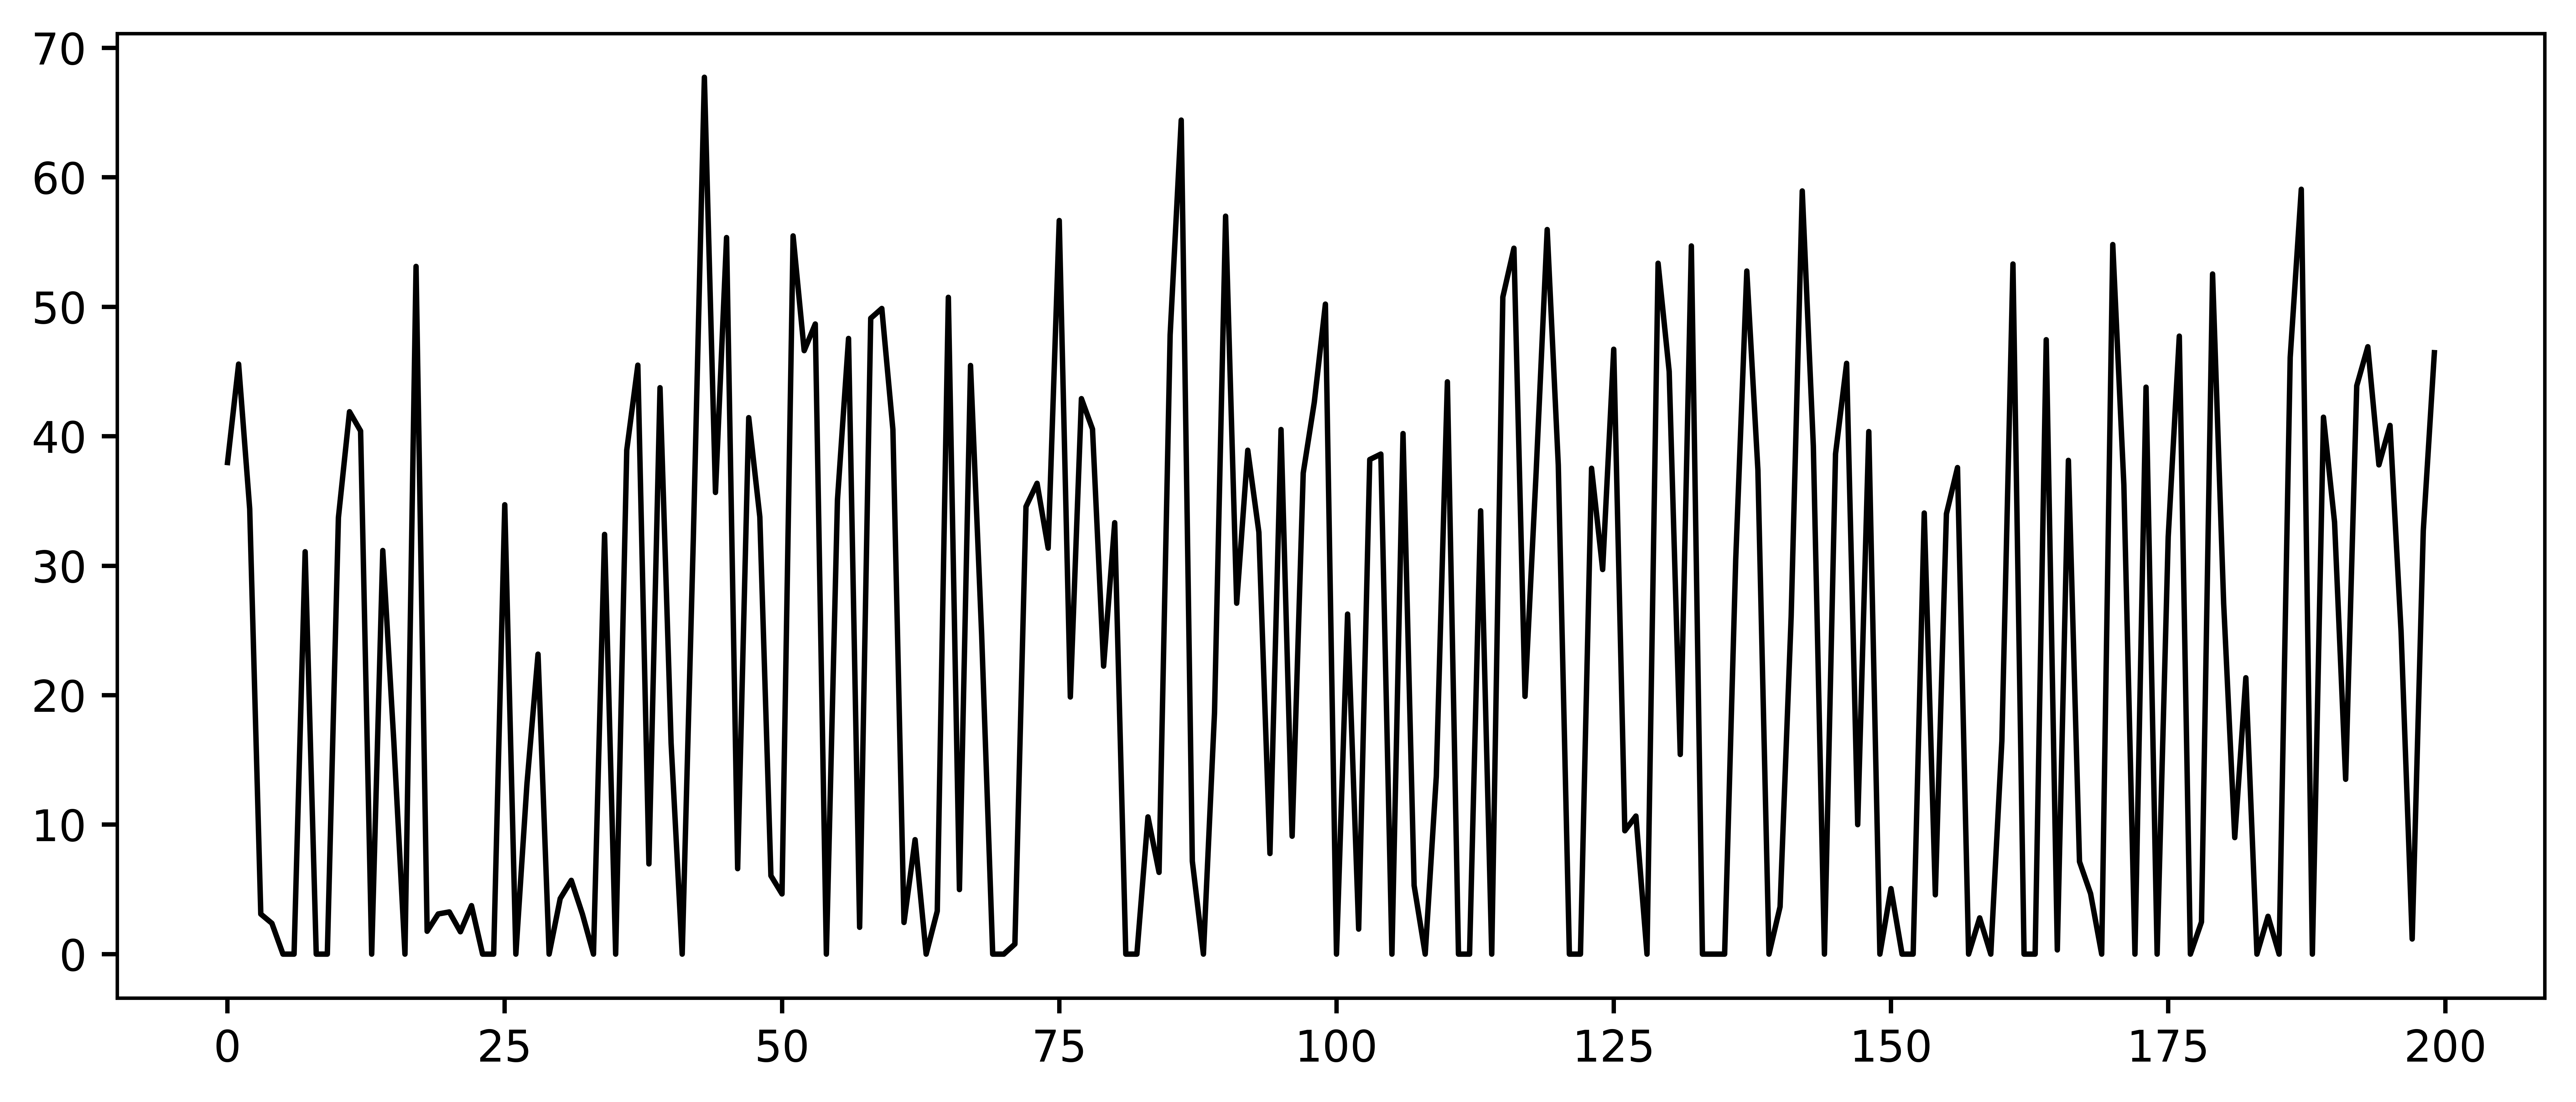

trial 877, neuron 358


In [4]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

run_dir = Path("..") / "data" / "memory_network_h512_n0.5_id2606221443"
RATE_MAX = 40.0

with h5py.File(run_dir / "gaussian.h5", "r") as f:
    act = f["0"]["area-A0"]  # (trials, time, neurons)
    i, j = np.random.randint(act.shape[0]), np.random.randint(act.shape[2])
    # i, j = 770, 335
    # i, j = 165, 61
    # i, j = 541, 73
    # i = np.random.randint(act.shape[0])
    # i, j = 854, 31
    rates = np.clip(RATE_MAX * (act[i, :, j] + 1) / 2, a_min=0, a_max=None)
    print(rates.mean())

fig, ax = plt.subplots(figsize=(10, 4), dpi=1000)
ax.plot(rates, color="black", lw=1.25)
ax.tick_params(width=1.0)
fig.savefig("neuron_rate.svg", bbox_inches="tight")
plt.show()
print(f"trial {i}, neuron {j}")


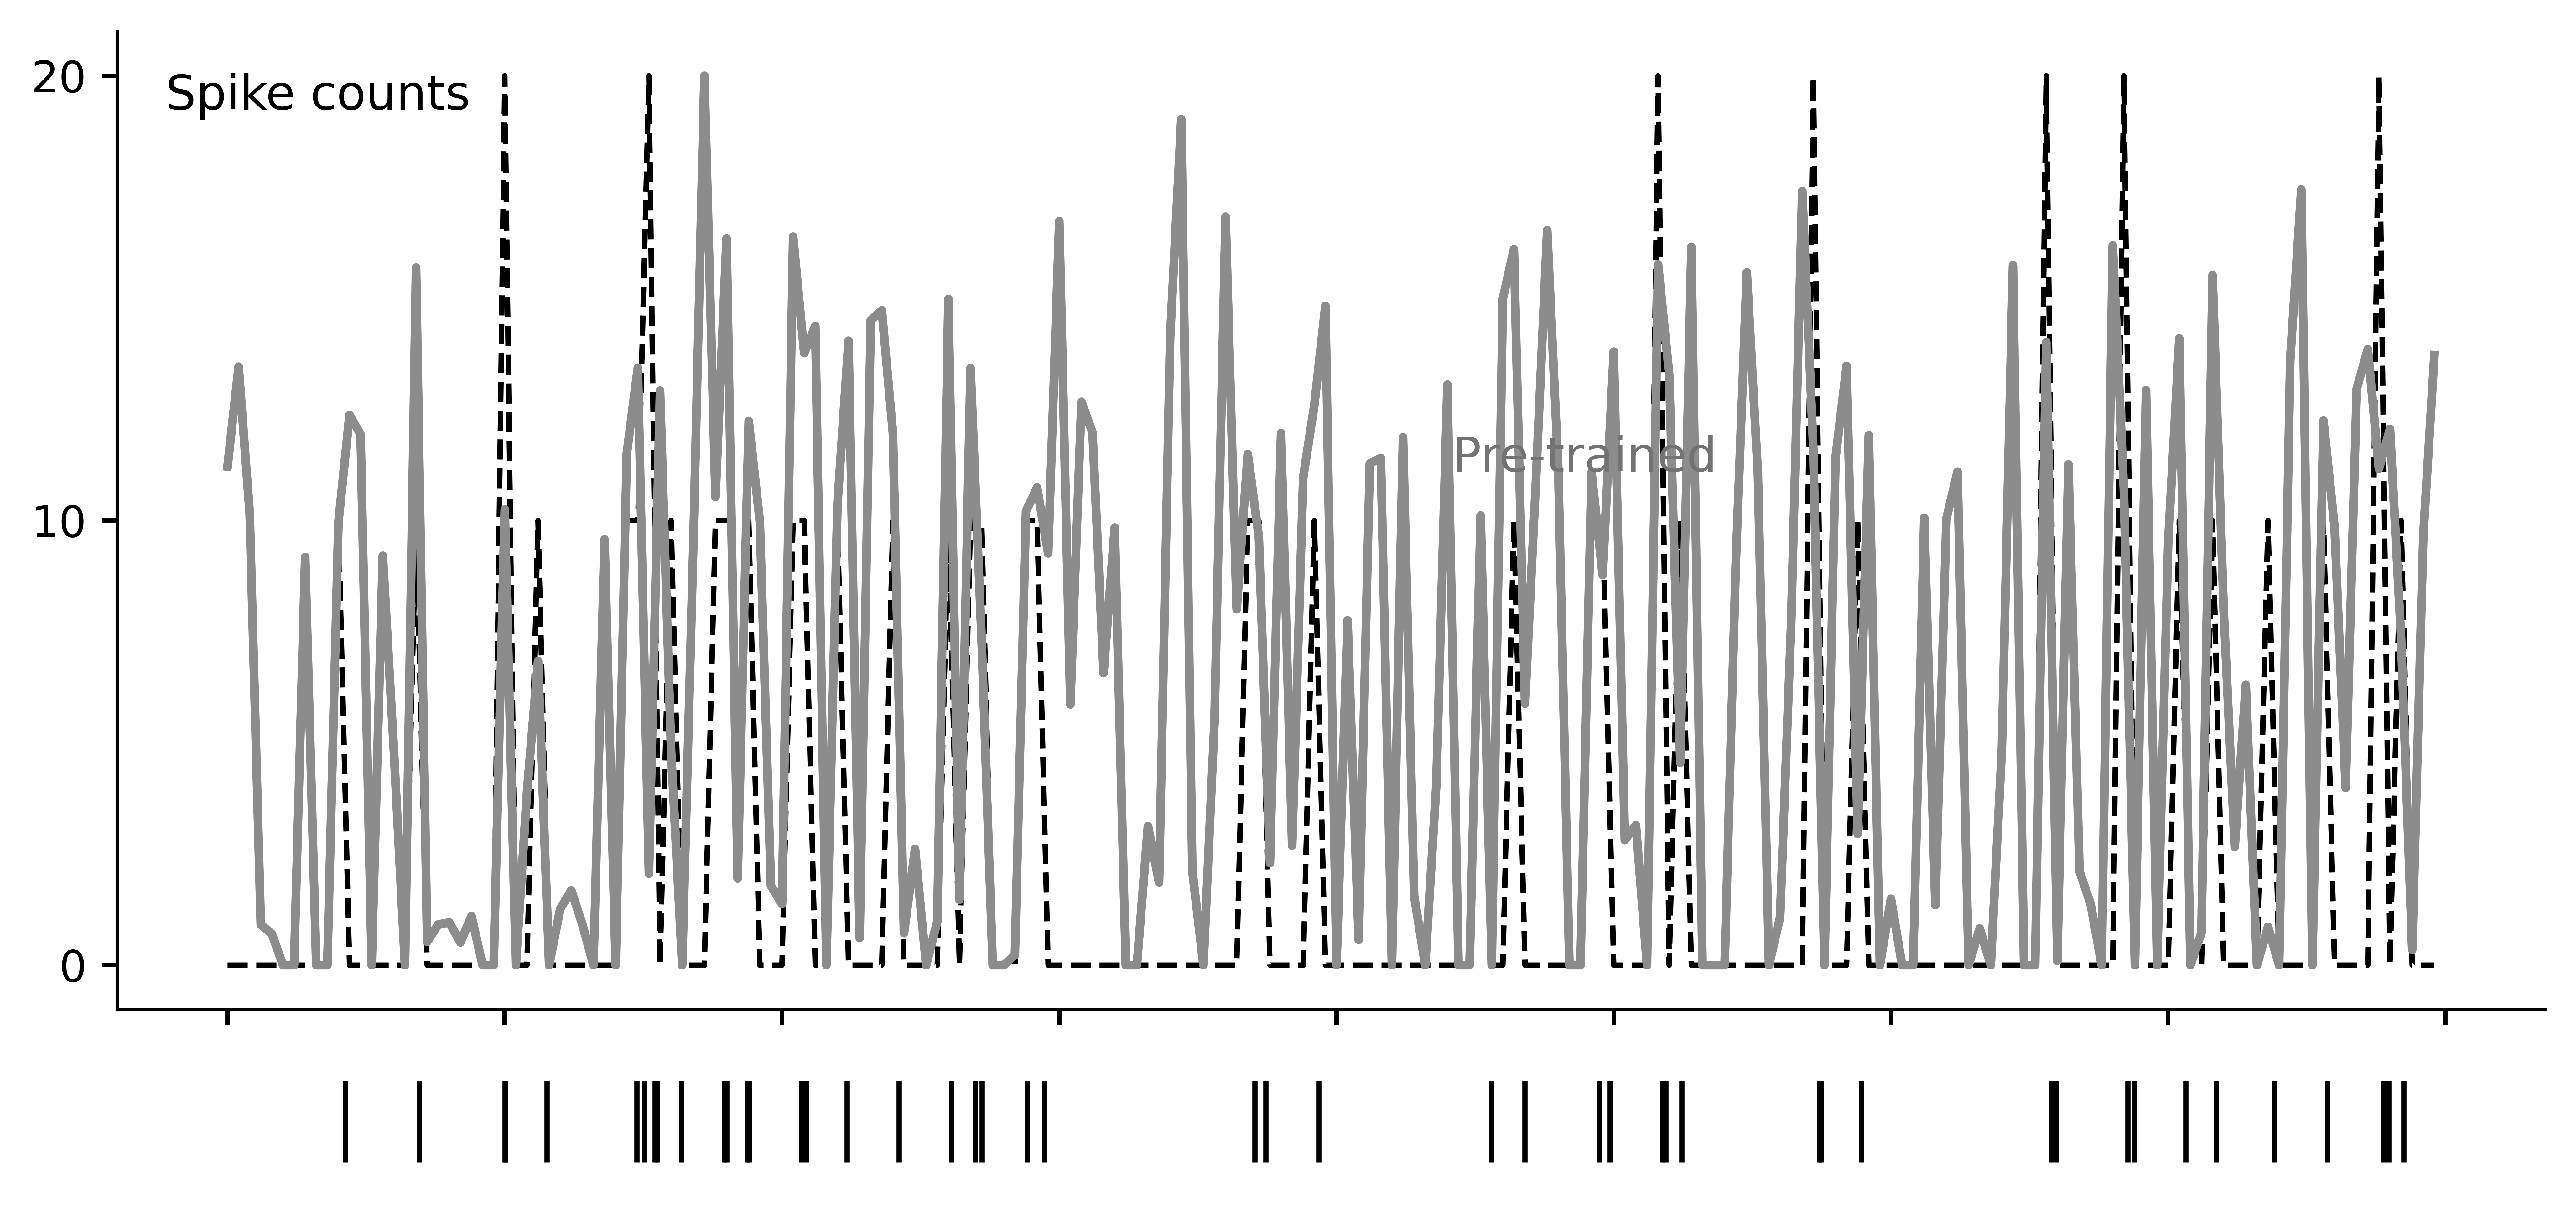

trial 877, neuron 358  mean count=0.23  n_spikes=47  (display ×10)


In [6]:
# Spike counts (same trial / neuron as rates cell above)
# Y-axis scaled ×10 for display (1 → 10, 2 → 20, ...); ticks every 10
# Spike train below: expand per-bin counts into event times (image-style raster)

from matplotlib.ticker import MultipleLocator

with h5py.File(run_dir / "data.h5", "r") as f:
    counts = f["0"]["area-A0"][i, :, j]

counts = np.asarray(counts).astype(int)
counts_scaled = counts * 10

# Place each bin's spikes uniformly inside [t, t+1)
rng = np.random.default_rng(0)
spike_times = (
    np.concatenate([t + rng.random(n) for t, n in enumerate(counts) if n > 0])
    if counts.sum() > 0
    else np.array([])
)

fig, (ax, ax_spk) = plt.subplots(
    2,
    1,
    figsize=(10, 4.8),
    dpi=1000,
    sharex=True,
    gridspec_kw={"height_ratios": [4, 0.55], "hspace": 0.08},
)

ax.plot(counts_scaled, color="black", lw=1.25, ls="--")
# rates from the cell above (gaussian → Hz); overlay as smooth reference
if "rates" in globals():
    rate_disp = rates * (counts_scaled.max() / max(float(rates.max()), 1e-8))
    ax.plot(rate_disp, color="0.55", lw=2.0)
    ax.text(0.02, 0.92, "Spike counts", transform=ax.transAxes, color="black", fontsize=11)
    ax.text(0.55, 0.55, "Pre-trained", transform=ax.transAxes, color="0.45", fontsize=11)

ax.yaxis.set_major_locator(MultipleLocator(10))
ax.tick_params(width=1.0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax_spk.eventplot(
    spike_times,
    orientation="horizontal",
    lineoffsets=0.0,
    linelengths=0.85,
    colors="black",
    linewidths=1.2,
)
ax_spk.set_ylim(-0.7, 0.7)
ax_spk.set_yticks([])
for spine in ax_spk.spines.values():
    spine.set_visible(False)
ax_spk.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)

fig.savefig("neuron_counts.svg", bbox_inches="tight")
plt.show()
print(
    f"trial {i}, neuron {j}  mean count={counts.mean():.2f}  "
    f"n_spikes={len(spike_times)}  (display ×10)"
)
